# Importar base de datos con sql

In [12]:
pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sqlite3
import pandas as pd

# Definir la ruta del archivo de la base de datos (Ruta relativa)
DB_PATH = 'data_accidentes (2).sqlite3'

# 1. Conexión a la base de datos SQLite con sqlite3 (Plantilla sugerida)
con = sqlite3.connect(DB_PATH)

# 2. Carga de las tablas mediante consultas SQL explícitas 'SELECT * FROM ...' 
# e interpretando 'TW' como tipo fecha nativo (parse_dates)
accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])

# 3. Cerrar la conexión convenientemente
con.close()
print("¡Conexión cerrada y tablas cargadas exitosamente en memoria!")

# 4. Verificación de las dimensiones de los DataFrames cargados
print("\n Resumen de dimensiones de las tablas cargadas")
print(f"Tabla 'accidentes': {accidentes.shape[0]} filas, {accidentes.shape[1]} columnas.")
print(f"Tabla 'clima': {clima.shape[0]} filas, {clima.shape[1]} columnas.")
print(f"Tabla 'raw_accidentes': {raw_accidentes.shape[0]} filas, {raw_accidentes.shape[1]} columnas.")

Iniciando conexión con la base de datos SQLite...
Ejecutando consultas SQL para cargar las tablas...
¡Conexión cerrada y tablas cargadas exitosamente en memoria!

--- Resumen de dimensiones de las tablas cargadas ---
Tabla 'accidentes': 120587 filas, 8 columnas.
Tabla 'clima': 7991780 filas, 15 columnas.
Tabla 'raw_accidentes': 125122 filas, 22 columnas.


#validar calidad de los datos

In [ ]:
#paso 4.2 del taller
import pandas as pd

def auditar_calidad_datos(df_accidentes, df_clima, df_raw):
    # 1. Análisis de Duplicados Totales
    print(f"- Registros idénticos duplicados en 'accidentes': {df_accidentes.duplicated().sum()}")
    print(f"- Registros idénticos duplicados en 'clima':      {df_clima.duplicated().sum()}")
    print(f"- Registros idénticos duplicados en 'raw_accid':  {df_raw.duplicated().sum()}")
    
    # 2. Análisis de integridad en las Llaves de Unión (TW, BARRIO)
    # En 'clima' y 'accidentes', la combinación de lugar y hora debería ser única
    dup_llave_clima = df_clima.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f"-> Duplicados de la llave compuesta (TW, BARRIO) en 'clima': {dup_llave_clima}")
    
    # 3. Análisis de Valores Faltantes (Nulos)
    for nombre, df in [('accidentes', df_accidentes), ('clima', df_clima), ('raw_accidentes', df_raw)]:
        nulos = df.isnull().sum()
        nulos_pct = (nulos / len(df)) * 100
        df_nulos = pd.DataFrame({'Cant Nulos': nulos, 'Porcentaje (%)': nulos_pct})
        df_nulos = df_nulos[df_nulos['Cant Nulos'] > 0]
        
        if not df_nulos.empty:
            print(f"\n[ALERTA] Valores faltantes en tabla '{nombre}':")
            print(df_nulos.round(2))
            
    # 4. TRATAMIENTO: Estandarización de texto en la columna BARRIO (Exigido en el punto 4.2)
    # Evita que " El Poblado " y "EL POBLADO" no crucen por culpa de espacios o minúsculas.
    print("\n[Tratamiento] Estandarizando cadenas de texto para la variable 'BARRIO'...")
    df_accidentes['BARRIO'] = df_accidentes['BARRIO'].astype(str).str.strip().str.upper()
    df_clima['BARRIO'] = df_clima['BARRIO'].astype(str).str.strip().str.upper()
    
    # 5. Verificación de coincidencia de Barrios
    barrios_acc = set(df_accidentes['BARRIO'].unique())
    barrios_cli = set(df_clima['BARRIO'].unique())
    
    discrepancias = barrios_acc.difference(barrios_cli)
    print(f"Cantidad de barrios en 'accidentes' que NO existen en 'clima': {len(discrepancias)}")
    if len(discrepancias) > 0:
        print(f"  barrios no concordantes: {list(discrepancias)[:5]}")
        
    return df_accidentes, df_clima

# Ejecutar la función de calidad pasando las variables que ya tienes cargadas
accidentes, clima = auditar_calidad_datos(accidentes, clima, raw_accidentes)


==================== INICIANDO AUDITORÍA DE CALIDAD ====================
-> Registros idénticos duplicados en 'accidentes': 0
-> Registros idénticos duplicados en 'clima':      0
-> Registros idénticos duplicados en 'raw_accid':  0
-> Duplicados de la llave compuesta (TW, BARRIO) en 'clima': 0

[ALERTA] Valores faltantes en tabla 'clima':
                     Cant Nulos  Porcentaje (%)
summary                  548641            6.87
icon                     548641            6.87
precipIntensity          547401            6.85
precipProbability        547401            6.85
temperature                 610            0.01
apparentTemperature         610            0.01
dewPoint                    305            0.00
humidity                    915            0.01
windSpeed                 32793            0.41
windBearing             1032513           12.92
cloudCover                 7950            0.10
uvIndex                    4280            0.05
visibility                 4290   

Punto 3, union de las tablas y creacion de var TARGET

In [ ]:



# 1. Creamos un dataframe temporal con las llaves de accidentes y marcamos presencia con un 1
df_accidentes_llaves = accidentes[['TW', 'BARRIO']].copy()
df_accidentes_llaves['TARGET'] = 1

# 2. Hacemos un LEFT JOIN usando la tabla 'clima' como el molde del universo completo.
# Esto asegura que mantendremos todas las horas y barrios del año, hayan tenido o no accidentes.
df_maestro = pd.merge(clima, df_accidentes_llaves, on=['TW', 'BARRIO'], how='left')

# 3. Aquellas combinaciones que no cruzaron (NaN) son los momentos donde NO hubo accidentes.
# Los llenamos con 0 como exige el modelo de clasificación.
df_maestro['TARGET'] = df_maestro['TARGET'].fillna(0).astype(int)

print("¡Fusión completada con éxito!")

# 4. Cálculo y reporte del desbalance de la variable objetivo (Exigido en el taller)
conteo_clases = df_maestro['TARGET'].value_counts()
proporcion_clases = df_maestro['TARGET'].value_counts(normalize=True) * 100

print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET) " )
print(f"Clase 0 (Sin Accidente): {conteo_clases[0]:,} observaciones ({proporcion_clases[0]:.2f}%)")
print(f"Clase 1 (Con Accidente): {conteo_clases[1]:,} observaciones ({proporcion_clases[1]:.2f}%)")

Iniciando la fusión de datos (Universo Clima + Presencia de Accidentes)...
¡Fusión completada con éxito!

=============== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (TARGET) ===============
Clase 0 (Sin Accidente): 7,871,305 observaciones (98.49%)
Clase 1 (Con Accidente): 120,475 observaciones (1.51%)


¿Cuál es la probabilidad de que ocurra al menos un accidente en el barrio B a la hora h
del día?

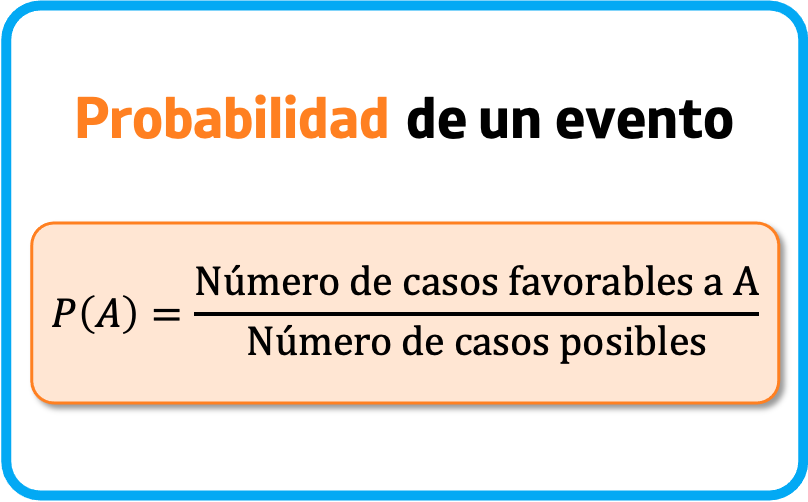

In [ ]:

# 1. Contar casos favorables (donde TARGET es 1)
casos_favorables = (df_maestro['TARGET'] == 1).sum()

# 2. Contar el universo total de observaciones (filas totales del dataframe maestro)
casos_totales = len(df_maestro)

# 3. Calcular la probabilidad empírica (Frecuencia Relativa)
probabilidad_accidente = casos_favorables / casos_totales

# 4. Mostrar el resultado formateado de manera elegante para el informe
print("calculo de probabilidad usando formula de arriba")
print(f"Casos Favorables (Con accidente):  {casos_favorables:,}")
print(f"Casos Totales (Universo de estudio): {casos_totales:,}")
print(f"Probabilidad (en valor decimal):    {probabilidad_accidente:.6f}")
print(f"Probabilidad (en porcentaje):       {probabilidad_accidente * 100:.2f}%")
print("-" * 45)

print(f"Entonces, la probabilidad marginal de que ocurra al menos un accidente en un barrio 'B'")
print(f"a una hora 'h' cualquiera en Medellín es del {probabilidad_accidente * 100:.2f}%.")

=== CÁLCULO MATEMÁTICO DE LA PROBABILIDAD ===
Casos Favorables (Con accidente):  120,475
Casos Totales (Universo de estudio): 7,991,780
Probabilidad (en valor decimal):    0.015075
Probabilidad (en porcentaje):       1.51%

> NOTA PARA EL INFORME:
La probabilidad marginal de que ocurra al menos un accidente en un barrio 'B'
a una hora 'h' cualquiera en Medellín es del 1.51%.


## Construcción de la variable objetivo (punto 3)

### 1. Definición de la unidad de análisis
* **Resolución Geográfica:** se dividieron los datos por barrio
* **Resolución Temporal:** la columna `TW se dividió por horas.
* **Cada fila de nuestra base de datos representa un bloque de una hora en un barrio específico de la ciudad (por ejemplo: Belén a las 5:00 p.m. del 10 de octubre). Esa es nuestra unidad de medida para predecir si hay o no un accidente

### 2. Construcción de los Casos Negativos (Parejas sin accidente)
Ya que solo se registran los datos si hubo accidentes (con un 1), cuando no hay accidentes decidimos usar la tabla clima para rellenar todos los momentox "tranqulos" ya que esa tabla tenia todas las fechas y las horas. entonces, en las fechas que hay un caso de accidentalidad se asigna un 1 al clima, de lo contrario (no hay conincidencias) se asigna 0.

### 3. Proporción de la Clase Positiva y Motivación del Proyecto
Los resultados obtenidos tras juntar ambos data sets arrojaron la siguiente distribución:

| Clase Target | Significado | Cantidad de Observaciones | Proporción (%) |
| :--- | :--- | :--- | :--- |
| **Clase 0** | Sin Accidente | 7,871,305 | 98.49% |
| **Clase 1** | Con Accidente | 120,475 | **1.51%** |

Lo cual se muestra como un modelo DESBALANCEADO, ya que tiene muy pocos casos positivos y muchos negativos, por lo que mas adelante debera usarse un metodo de balance de datos para arreglar este problema. 
